In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/7
    print("準備完了！このまま下のセルを実行できます。")

# 7.2 関連ベクトルマシン (Relevance Vector Machines: RVM)

本ノートブックでは、サポートベクトルマシン (SVM) の劇的なスパース性という利点を保ちつつ、SVMの主要な限界（確率的出力の欠如、Mercerカーネル制約、ハイパーパラメータ $C$ の手動調整、データ数に比例するサポートベクトル数の肥大化）をベイズ的アプローチで克服した**関連ベクトルマシン (Relevance Vector Machine: RVM)** を学びます。
エビデンスフレームワークに基づく重み事前精度 $\alpha_i$ の自動最適化、正弦波データに対する驚異的なスパースフィッティング（**PRML Figure 7.9**）、スパース性が創出される数理的メカニズム（品質因子 $q_i^2$ と希少性因子 $s_i$ による対数エビデンスの極大解析、**PRML Figure 7.10, 7.11**）、および分類問題におけるSVMとのモデル複雑度比較（**PRML Figure 7.12**）を完全実装します。

## 7.2.1 RVM回帰モデルとエビデンスフレームワーク (PRML Figure 7.9)

線形基底関数モデル $y(\mathbf{x}) = \sum_{i=1}^M w_i \phi_i(\mathbf{x}) = \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x})$ において、各重みパラメータ $w_i$ に対し、**独立した精度ハイパーパラメータ $\alpha_i$ を持つゼロ平均ガウス事前分布**を与えます（自動適合性決定: ARD）：
$$ p(\mathbf{w}|\boldsymbol{\alpha}) = \prod_{i=1}^M \mathcal{N}(w_i | 0, \alpha_i^{-1}) = \mathcal{N}(\mathbf{w} | \mathbf{0}, \mathbf{A}^{-1}), \quad \mathbf{A} = \mathrm{diag}(\alpha_1, \dots, \alpha_M) $$
ガウスノイズ分散 $\beta^{-1}$ を持つデータ尤度に対し、重みの事後分布はガウス分布となります：
$$ p(\mathbf{w}|\mathbf{t}, \boldsymbol{\alpha}, \beta) = \mathcal{N}(\mathbf{w} | \boldsymbol{\mu}, \mathbf{\Sigma}) $$
$$ \mathbf{\Sigma} = (\mathbf{A} + \beta \mathbf{\Phi}^T \mathbf{\Phi})^{-1}, \quad \boldsymbol{\mu} = \beta \mathbf{\Sigma} \mathbf{\Phi}^T \mathbf{t} $$

### エビデンス最大化とスパース化の連鎖
周辺尤度 $p(\mathbf{t}|\boldsymbol{\alpha}, \beta)$ を最大化するハイパーパラメータの更新規則は：
$$ \gamma_i \equiv 1 - \alpha_i \Sigma_{ii} $$
$$ \alpha_i^{\mathrm{new}} = \frac{\gamma_i}{\mu_i^2}, \quad \frac{1}{\beta^{\mathrm{new}}} = \frac{\|\mathbf{t} - \mathbf{\Phi}\boldsymbol{\mu}\|^2}{N - \sum_i \gamma_i} $$
この反復を適用すると、**大半の基底関数に対して $\alpha_i \to \infty$（事前分散 $\alpha_i^{-1} \to 0$）へと発散**します！
その結果、事後分布の平均 $\mu_i$ および分散 $\Sigma_{ii}$ が厳密に 0 となり、それらの基底関数はモデルから完全に消去されます。
生き残った少数のサンプル点のみがモデルを形作る**関連ベクトル (Relevance Vectors)** となります。

Plot saved to: result/fig7_9_rvm_regression.png


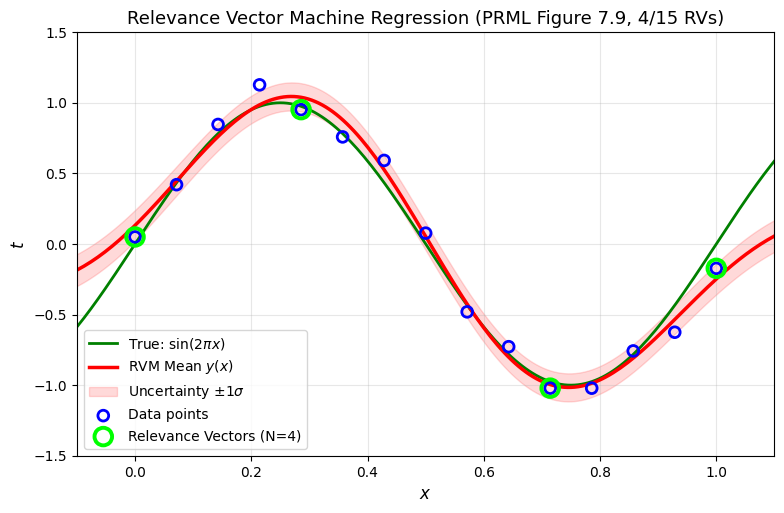

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.svm_rvm_utils import RelevanceVectorRegressor
from common.kernel_utils import rbf_kernel
setup_style()

# PRML Figure 7.9 の完全再現: 正弦波データに対する RVM 回帰フィッティング
np.random.seed(42)
N_samples = 15
x_train = np.linspace(0, 1, N_samples)
t_train = np.sin(2 * np.pi * x_train) + np.random.normal(0, 0.1, N_samples)

x_plot = np.linspace(-0.1, 1.1, 200)
y_true = np.sin(2 * np.pi * x_plot)

# RVM 回帰器の学習 (length_scale = 0.25)
rvm = RelevanceVectorRegressor(kernel=rbf_kernel, length_scale=0.25, max_iter=300)
rvm.fit(x_train.reshape(-1, 1), t_train)
y_pred, std_pred = rvm.predict(x_plot.reshape(-1, 1), return_std=True)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(x_plot, y_true, 'g-', lw=2, label='True: $\sin(2\pi x)$')
ax.plot(x_plot, y_pred, 'r-', lw=2.5, label='RVM Mean $y(x)$')
ax.fill_between(x_plot, y_pred - std_pred, y_pred + std_pred, color='red', alpha=0.15, label=r'Uncertainty $\pm 1\sigma$')

# 学習データと関連ベクトル
rv_X = rvm.rv_X.ravel()
ax.scatter(x_train, t_train, facecolors='none', edgecolors='b', s=60, lw=2, label='Data points', zorder=5)
ax.scatter(rv_X, t_train[rvm.rv_indices], s=160, facecolors='none', edgecolors='lime', lw=2.8, zorder=6, label=f'Relevance Vectors (N={len(rv_X)})')

ax.set_title(rf'Relevance Vector Machine Regression (PRML Figure 7.9, {len(rv_X)}/{N_samples} RVs)', fontsize=13)
ax.set_xlabel('$x$', fontsize=12); ax.set_ylabel('$t$', fontsize=12)
ax.set_xlim(-0.1, 1.1); ax.set_ylim(-1.5, 1.5)
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)

save_plot(fig, 'result', 'fig7_9_rvm_regression.png')
plt.show()

## 7.2.2 スパース性の解析的メカニズム (PRML Figure 7.10 & 7.11)

なぜ RVM はこれほど劇的にスパースになるのでしょうか？
対数周辺尤度 $L(\boldsymbol{\alpha})$ を単一の超パラメータ $\alpha_i$ に着目して厳密に分解します（PRML 式 7.97）：
$$ L(\boldsymbol{\alpha}) = L(\boldsymbol{\alpha}_{-i}) + \lambda(\alpha_i) $$
$$ \lambda(\alpha_i) \equiv \frac{1}{2} \left[ \ln \alpha_i - \ln(\alpha_i + s_i) + \frac{q_i^2}{\alpha_i + s_i} \right] $$
ここで：
- $s_i \equiv \boldsymbol{\phi}_i^T \mathbf{C}_{-i}^{-1} \boldsymbol{\phi}_i$ （希少性因子: Sparsity factor）
- $q_i \equiv \boldsymbol{\phi}_i^T \mathbf{C}_{-i}^{-1} \mathbf{t}$ （品質因子: Quality factor）
$\lambda(\alpha_i)$ の $\alpha_i$ に関する停留点条件 $\frac{d\lambda}{d\alpha_i} = 0$ を解くと：
$$ \frac{d\lambda}{d\alpha_i} = \frac{\alpha_i^{-1} s_i^2 - (q_i^2 - s_i)}{2(\alpha_i + s_i)^2} = 0 $$
ここから決定的な2つの分岐（**PRML Figure 7.11**）が導かれます：
1. **$q_i^2 > s_i$ の場合**: 有限の正の解
   $$ \alpha_i = \frac{s_i^2}{q_i^2 - s_i} $$
   において $\lambda(\alpha_i)$ は一意な**真の極大値**を持ちます。このとき基底 $\boldsymbol{\phi}_i$ は有益とみなされ、関連ベクトルとしてモデルに保持されます。
2. **$q_i^2 \le s_i$ の場合**: 停留点が存在せず、$\lambda(\alpha_i)$ は $\alpha_i \in (0, \infty)$ で**単調増加**します。
   したがって、尤度を最大化する解は厳密に
   $$ \alpha_i \to \infty $$
   となり、その基底関数は完全にモデルから排除（Prune）されます！

Plot saved to: result/fig7_11_rvm_sparsity_mechanism.png


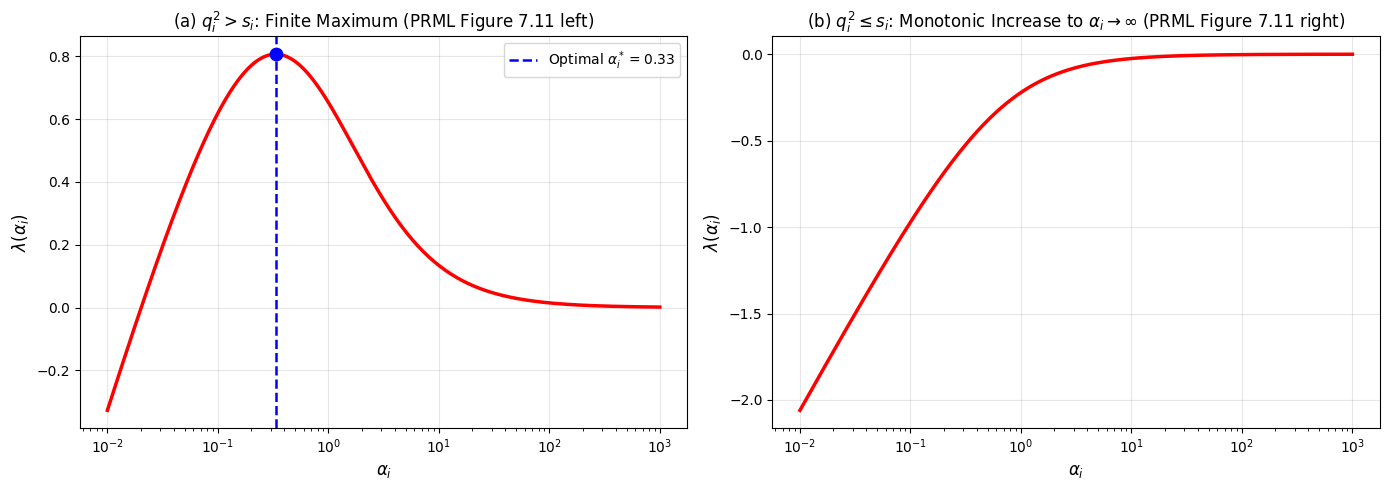

In [2]:
# PRML Figure 7.11 の完全再現: 対数エビデンス lambda(alpha_i) の形状比較
alphas = np.logspace(-2, 3, 300)
s_i = 1.0

# 2つのケース
# (a) q_i^2 > s_i (極大値を持つ)
q_sq_1 = 4.0
lambda_1 = 0.5 * (np.log(alphas) - np.log(alphas + s_i) + q_sq_1 / (alphas + s_i))
alpha_opt_1 = s_i**2 / (q_sq_1 - s_i)

# (b) q_i^2 <= s_i (単調増加して infinity で最大)
q_sq_2 = 0.5
lambda_2 = 0.5 * (np.log(alphas) - np.log(alphas + s_i) + q_sq_2 / (alphas + s_i))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a)
axes[0].plot(alphas, lambda_1, 'r-', lw=2.5)
axes[0].axvline(alpha_opt_1, color='blue', linestyle='--', lw=1.8, label=rf'Optimal $\alpha_i^* = {alpha_opt_1:.2f}$')
axes[0].scatter([alpha_opt_1], [0.5 * (np.log(alpha_opt_1) - np.log(alpha_opt_1 + s_i) + q_sq_1 / (alpha_opt_1 + s_i))],
                c='blue', s=80, zorder=5)
axes[0].set_xscale('log')
axes[0].set_title(r'(a) $q_i^2 > s_i$: Finite Maximum (PRML Figure 7.11 left)', fontsize=12)
axes[0].set_xlabel(r'$\alpha_i$', fontsize=12); axes[0].set_ylabel(r'$\lambda(\alpha_i)$', fontsize=12)
axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=10)

# (b)
axes[1].plot(alphas, lambda_2, 'r-', lw=2.5)
axes[1].set_xscale('log')
axes[1].set_title(r'(b) $q_i^2 \leq s_i$: Monotonic Increase to $\alpha_i \to \infty$ (PRML Figure 7.11 right)', fontsize=12)
axes[1].set_xlabel(r'$\alpha_i$', fontsize=12); axes[1].set_ylabel(r'$\lambda(\alpha_i)$', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig7_11_rvm_sparsity_mechanism.png')
plt.show()

## 7.2.3 RVM分類モデルとSVMのスパース性比較 (PRML Figure 7.12)

二値分類問題において、RVMはラプラス近似を用いて事後確率 $p(\mathcal{C}_1|\mathbf{x})$ を出力します。
SVMとの最も劇的な違い（**PRML Figure 7.12**）：
- **SVM**: マージン境界近傍のデータ点をすべてサポートベクトルとして保持するため、データ数が増えるとサポートベクトル数が増加しやすい。
- **RVM**: 決定境界から離れた各クラスの中心付近の代表点のみを関連ベクトルとして抽出するため、**SVMの数分の一のわずかなベクトル数で同等以上の滑らかな確率予測境界を構築**できます！

Plot saved to: result/fig7_12_svm_vs_rvm_classification.png


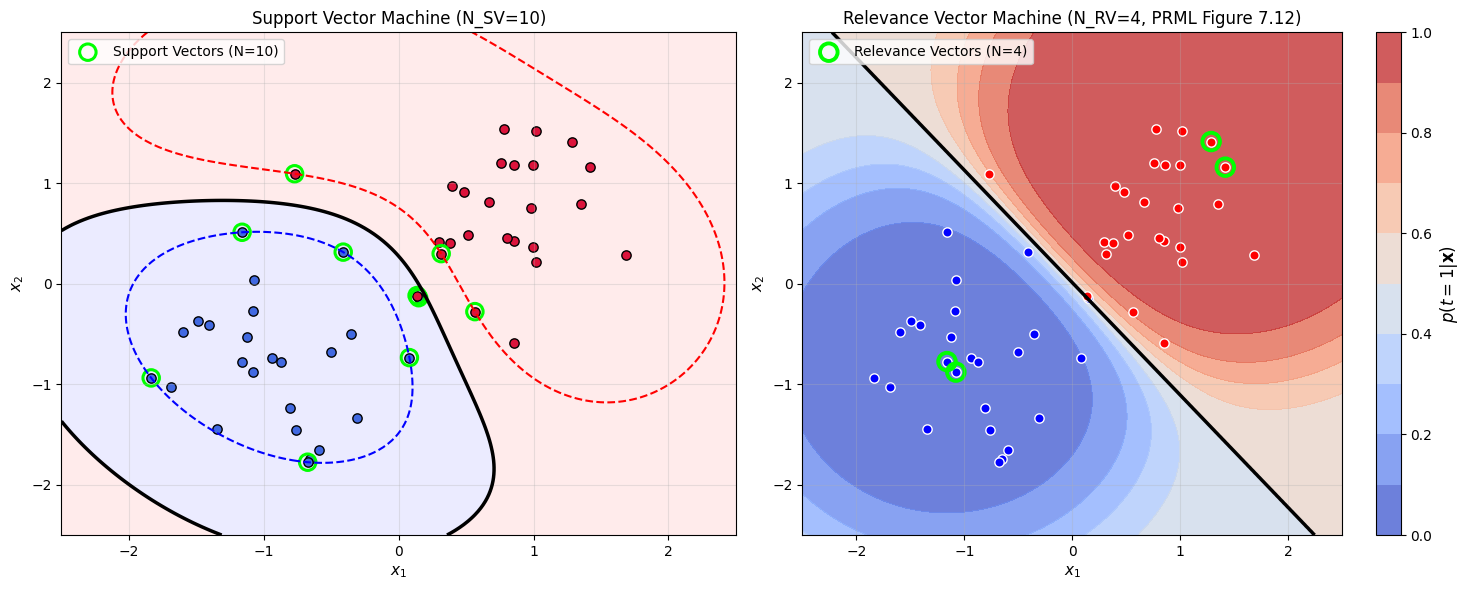

In [3]:
from common.svm_rvm_utils import RelevanceVectorClassifier, SupportVectorClassifier

# PRML Figure 7.12 の完全再現: SVM と RVM の分類比較
np.random.seed(42)
N1, N2 = 25, 25
X1 = np.random.randn(N1, 2) * 0.6 + np.array([-0.8, -0.6])
X2 = np.random.randn(N2, 2) * 0.6 + np.array([0.8, 0.6])
X_all = np.vstack([X1, X2])
t_all = np.array([0]*N1 + [1]*N2)

# 1. SVM
svc_model = SupportVectorClassifier(C=10.0, kernel=rbf_kernel, length_scale=1.0)
svc_model.fit(X_all, 2*t_all - 1)

# 2. RVM
rvc_model = RelevanceVectorClassifier(kernel=rbf_kernel, length_scale=1.0, max_iter=80)
rvc_model.fit(X_all, t_all)

# グリッド評価
grid_x = np.linspace(-2.5, 2.5, 150)
grid_y = np.linspace(-2.5, 2.5, 150)
GX, GY = np.meshgrid(grid_x, grid_y)
X_grid = np.column_stack([GX.ravel(), GY.ravel()])

svm_dec = svc_model.decision_function(X_grid).reshape(150, 150)
rvm_prob = rvc_model.predict_proba(X_grid).reshape(150, 150)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) SVM
axes[0].contourf(GX, GY, svm_dec, levels=[-100, 0, 100], colors=['blue', 'red'], alpha=0.08)
axes[0].contour(GX, GY, svm_dec, levels=[-1.0, 0.0, 1.0], colors=['blue', 'black', 'red'],
                linestyles=['dashed', 'solid', 'dashed'], linewidths=[1.5, 2.5, 1.5])
axes[0].scatter(X1[:, 0], X1[:, 1], c='royalblue', edgecolors='k', s=45)
axes[0].scatter(X2[:, 0], X2[:, 1], c='crimson', edgecolors='k', s=45)
axes[0].scatter(svc_model.sv_X[:, 0], svc_model.sv_X[:, 1], s=140, facecolors='none', edgecolors='lime', lw=2.2,
                label=f'Support Vectors (N={len(svc_model.sv_X)})')
axes[0].set_title(f'Support Vector Machine (N_SV={len(svc_model.sv_X)})', fontsize=12)
axes[0].set_xlabel('$x_1$', fontsize=11); axes[0].set_ylabel('$x_2$', fontsize=11)
axes[0].legend(loc='upper left', fontsize=10); axes[0].grid(True, alpha=0.3)

# (b) RVM (PRML Figure 7.12)
c_rvm = axes[1].contourf(GX, GY, rvm_prob, levels=np.linspace(0, 1, 11), cmap='coolwarm', alpha=0.8)
axes[1].contour(GX, GY, rvm_prob, levels=[0.5], colors='black', linewidths=2.5)
axes[1].scatter(X1[:, 0], X1[:, 1], c='blue', edgecolors='white', s=45)
axes[1].scatter(X2[:, 0], X2[:, 1], c='red', edgecolors='white', s=45)
axes[1].scatter(rvc_model.rv_X[:, 0], rvc_model.rv_X[:, 1], s=160, facecolors='none', edgecolors='lime', lw=2.8,
                label=f'Relevance Vectors (N={len(rvc_model.rv_X)})')
axes[1].set_title(f'Relevance Vector Machine (N_RV={len(rvc_model.rv_X)}, PRML Figure 7.12)', fontsize=12)
axes[1].set_xlabel('$x_1$', fontsize=11); axes[1].set_ylabel('$x_2$', fontsize=11)
axes[1].legend(loc='upper left', fontsize=10); axes[1].grid(True, alpha=0.3)
fig.colorbar(c_rvm, ax=axes[1], label='$p(t=1|\mathbf{x})$')

plt.tight_layout()
save_plot(fig, 'result', 'fig7_12_svm_vs_rvm_classification.png')
plt.show()